# What the Philadelphia Shooting Data Tells Us

Philadelphia’s shootings data is easy to reduce to one big number. But the more interesting story is in the patterns: when shootings peaked, who is most affected, where incidents happen, and what stays surprisingly stable over time.

This dataset includes more than **17,500 shooting victims** in Philadelphia. Looking more closely, the violence is not random. It is concentrated in very specific ways.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.simplefilter('ignore')

shoot_df = pd.read_csv('shootings.csv')

race_mapping = {
    'B': 'BLACK',
    'W': 'WHITE',
    'A': 'ASIAN',
    'I': 'INDIGENOUS',
    'U': 'UNIDENTIFIED/OTHER',
    'O': 'OTHER'
}

latino_mapping = {
    0: 'NON-LATINO',
    1: 'LATINO'
}

shoot_df['race_long'] = shoot_df['race'].map(race_mapping)
shoot_df['latino_long'] = shoot_df['latino'].map(latino_mapping)
shoot_df['ethnicity'] = shoot_df['race_long'] + ' ' + shoot_df['latino_long']

bins = [0, 9, 19, 29, 39, 49, 59, 69, 79, 100]
labels = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]
shoot_df['age_group'] = pd.cut(shoot_df['age'], bins=bins, labels=labels)

## Shootings peaked in the early 2020s

One of the clearest patterns in the dataset is the rise in shooting victims during the early 2020s. The highest year in the dataset is **2021**, followed closely by **2022** and **2020**.

That matters on its own, but it also sets up the bigger question: did the deeper structure of the violence change too, or just the scale?

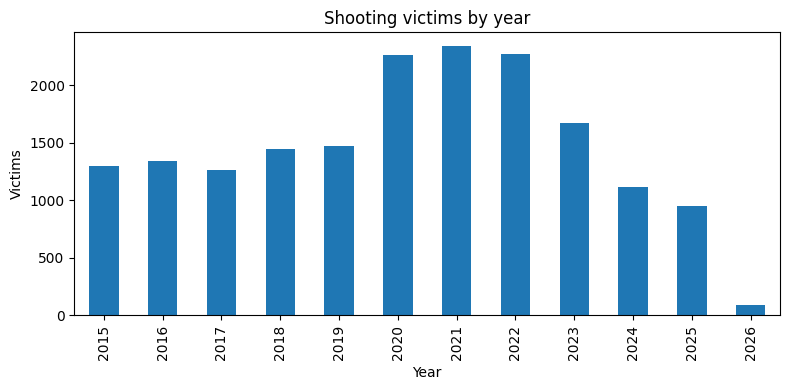

In [17]:
year_counts = shoot_df['year'].value_counts().sort_index()

plt.figure(figsize=(8,4))
year_counts.plot(kind='bar')
plt.title('Shooting victims by year')
plt.xlabel('Year')
plt.ylabel('Victims')
plt.tight_layout()
plt.show()

## Most victims are young adults

The age breakdown is one of the strongest parts of the story. The average victim is about **29 years old**, and the largest age group by far is people in their **20s**.

This means the dataset is not spread evenly across the population. It is heavily concentrated among younger Philadelphians.

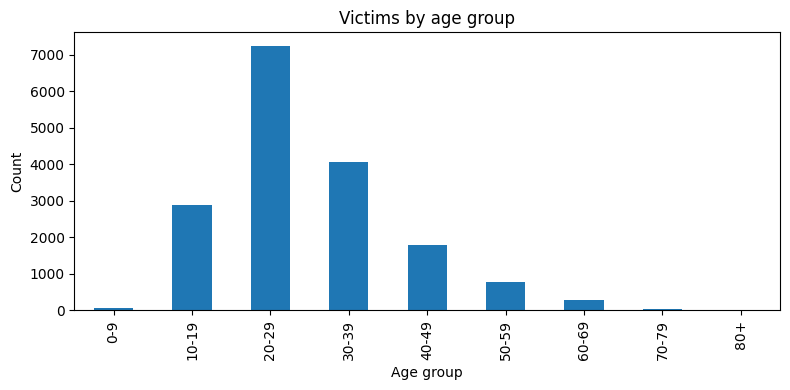

In [18]:
age_counts = shoot_df['age_group'].value_counts().sort_index()

plt.figure(figsize=(8,4))
age_counts.plot(kind='bar')
plt.title('Victims by age group')
plt.xlabel('Age group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Shootings are overwhelmingly outside

Another pattern is even more dramatic: shootings happen far more often **outside** than inside.

This makes the violence feel less hidden and more public. The streets, sidewalks, and shared spaces of the city are where most of these incidents are taking place.

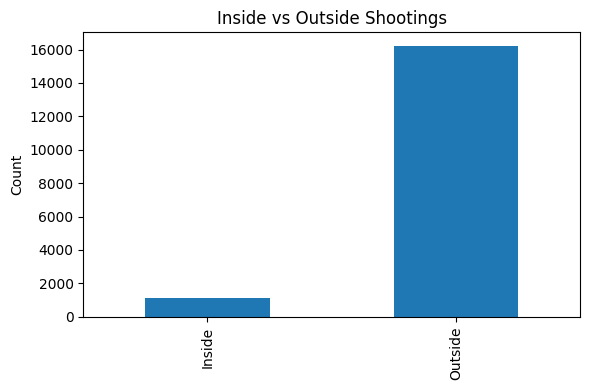

In [19]:
inside = shoot_df['inside'].value_counts().get(1.0, 0)
outside = shoot_df['outside'].value_counts().get(1.0, 0)

location_counts = pd.Series({'Inside': inside, 'Outside': outside})

plt.figure(figsize=(6,4))
location_counts.plot(kind='bar')
plt.title('Inside vs Outside Shootings')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## The burden is not evenly distributed

The race and ethnicity breakdown makes clear that shootings do not affect all groups equally. The largest category in the dataset is **Black non-Latino victims**, far exceeding every other group.

This is one of the most important findings in the notebook because it shows that the violence is concentrated not only by age and place, but also across communities.

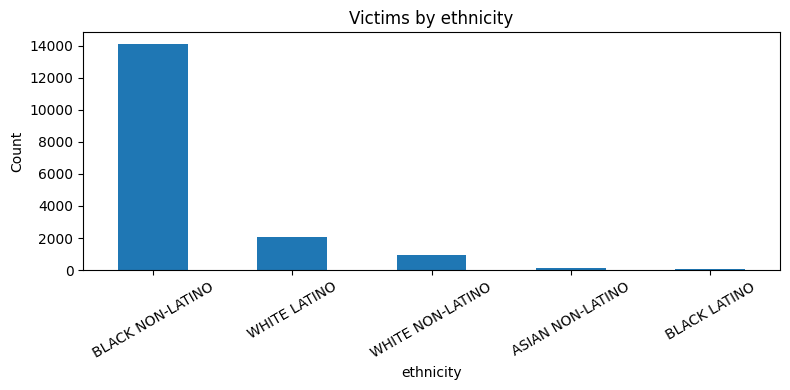

In [20]:
eth_counts = shoot_df['ethnicity'].value_counts().head(5)

plt.figure(figsize=(8,4))
eth_counts.plot(kind='bar')
plt.title('Victims by ethnicity')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## The twist: the fatal share stays fairly stable

The most surprising pattern may be what does **not** change very much. Even though the total number of shooting victims rises and falls, the percentage of shootings that are fatal stays in a fairly narrow range, around **20%**.

So the scale changes, but the structure remains remarkably consistent.

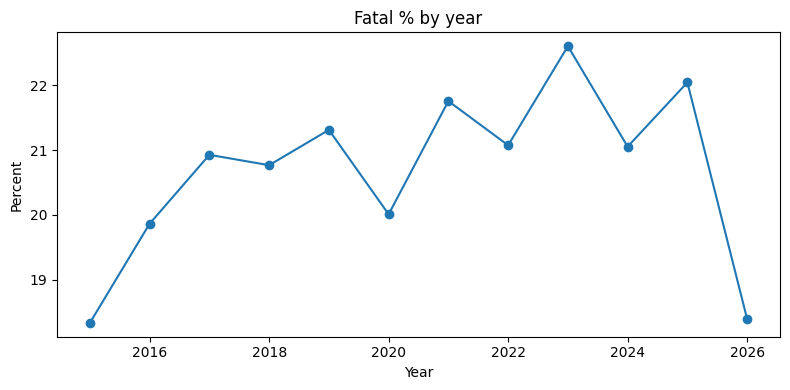

In [21]:
fatal_share = shoot_df.groupby('year')['fatal'].mean() * 100

plt.figure(figsize=(8,4))
fatal_share.plot(marker='o')
plt.title('Fatal % by year')
plt.xlabel('Year')
plt.ylabel('Percent')
plt.tight_layout()
plt.show()

## Conclusion

Philadelphia’s shootings data shows that violence in the city is not random.

It is concentrated:
- in the **early 2020s**
- among **young adults**
- overwhelmingly **outside**
- and disproportionately in **specific communities**

The biggest takeaway is not just how many shootings happen. It is how consistently they follow the same patterns.

That consistency is what makes the dataset so powerful — and so disturbing.